In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [36]:
from GraphSimulation import (
    TripartiteGraph,
    MatchingStrategy, GreedyStrategy, RankStrategy
)

In [37]:
n_Inodes = 10
n_Lnodes = 10
n_Rnodes = 10

INT_MAX = int(1e6)
OPTIMAL = min(n_Lnodes, n_Inodes, n_Rnodes)

In [38]:
def generate_varNodes(inode_ids, n_Lnodes, n_Inodes, n_Rnodes, shuffle=False, seed= None):
    rand_gen = np.random.default_rng(seed)
    nodes = []

    # Generate L nodes
    for _ in range(n_Lnodes):
        k = rand_gen.integers(1, n_Inodes + 1)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("L", candidates))

    # Generate R nodes
    for _ in range(n_Rnodes):
        k = rand_gen.integers(1, n_Inodes + 1)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("R", candidates))

    if shuffle: rand_gen.shuffle(nodes)
    return nodes

def simulate_online(graph: TripartiteGraph, node_order):
    for time, (node_type, candidates) in enumerate(node_order):
        if node_type == "L":
            graph.add_Lnode(time, candidates)
        else:
            graph.add_Rnode(time, candidates)
    return graph.matches

### helper functions to load datset

In [ ]:
def extract_params(filepath: str):
    df = pd.read_csv(filepath)

    job_titles=df['job_title'].unique().tolist()
    n_Inodes=len(job_titles)
    inode_ids=list(range(n_Inodes))
    n_Lnodes=df['salary_currency'].nunique()
    n_Rnodes=df['employee_residence'].nunique()

    return inode_ids, n_Lnodes, n_Inodes, n_Rnodes

inode_ids, n_Lnodes, n_Inodes, n_Rnodes = extract_params("ds_salaries.csv")
node_order = generate_varNodes(inode_ids, n_Lnodes, n_Inodes, n_Rnodes, shuffle=True, seed=42)

In [40]:
def run_experiment(strategy: MatchingStrategy, runs=100, 
                n_inodes= n_Inodes, n_lnodes=n_Lnodes, n_rnodes=n_Rnodes, 
                seed:int|None= None):
    results_online = []
    rand_gen = np.random.default_rng(seed)

    # Create the Graph
    g = TripartiteGraph(strategy, n_inodes)
    inode_ids = list(g.Inodes.keys())

    # Generate the nodes order
    node_order = generate_varNodes(inode_ids,
                        n_lnodes, n_inodes, n_rnodes, seed=seed)

    pbar = tqdm(range(runs), desc=f'Simulating: {strategy.name}')
    for _ in pbar:
        # Shuffle Nodes
        rand_gen.shuffle(node_order)

        # Online
        matches_online = simulate_online(g, node_order)
        results_online.append(matches_online)

        # Reset Graph
        g.reset()
    return results_online

In [41]:
RUN_SEED = 42
greedy_res = run_experiment(GreedyStrategy(), seed= RUN_SEED)
rank_res = run_experiment(RankStrategy(), seed= RUN_SEED)

Simulating: RankStrategy: 100%|██████████| 100/100 [00:00<00:00, 367.24it/s]


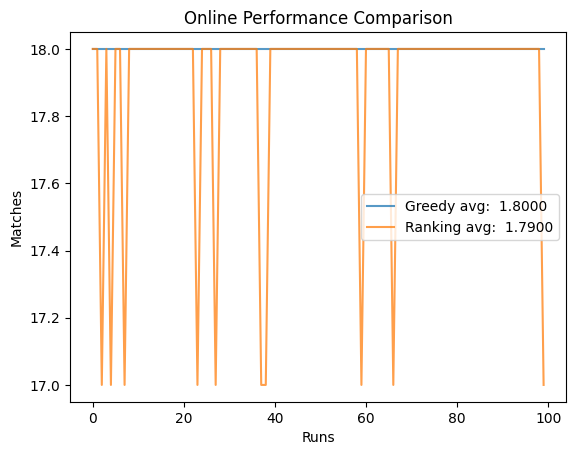

In [42]:
def plot_results(greedy_res, rank_res, optimal= OPTIMAL):
    plt.plot(greedy_res, alpha=0.75, label=f"Greedy avg: {np.average(greedy_res) / optimal: .4f}")
    plt.plot(rank_res, alpha=0.75, label=f"Ranking avg: {np.average(rank_res) / optimal: .4f}")

    plt.title("Online Performance Comparison")
    plt.xlabel("Runs")
    plt.ylabel("Matches")

    plt.legend()
    plt.show()

plot_results(greedy_res, rank_res)